# Carga de datos

In [ ]:
#Importamos librerias necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install sodapy

In [ ]:
from sodapy import Socrata


# Cliente sin token (puedes poner uno si lo tienes)
client = Socrata("www.datos.gov.co", None)

#ID del dataset (puedes cambiarlo)
dataset_id = "4iz7-suhz"

# Parámetros de paginación
limit = 1000
offset = 0
all_results = []

while True:
    results = client.get(dataset_id, limit=limit, offset=offset)
    if not results:
        break
    all_results.extend(results)
    offset += limit
    print(f"{offset} registros descargados...")

# Convertir todo a DataFrame
df = pd.DataFrame.from_records(all_results)

# Exportar a CSV
ruta_salida_etl = '/content/drive/MyDrive/1. Proyectos/e. Proyecto Predicción de enfermedades crónicas en Bucaramanga/Datasets/bucaramanga_enfermedades_cronicas.csv'
df.to_csv(ruta_salida_etl, index=False, encoding='utf-8-sig')

# Mostrar resumen
print(f"Total de registros descargados: {len(df)}")
#print(df.head())

1000 registros descargados...
2000 registros descargados...
3000 registros descargados...
4000 registros descargados...
5000 registros descargados...
6000 registros descargados...
7000 registros descargados...
8000 registros descargados...
9000 registros descargados...
10000 registros descargados...
11000 registros descargados...
12000 registros descargados...
13000 registros descargados...
14000 registros descargados...
15000 registros descargados...
16000 registros descargados...
17000 registros descargados...
18000 registros descargados...
19000 registros descargados...
20000 registros descargados...
21000 registros descargados...
22000 registros descargados...
23000 registros descargados...
24000 registros descargados...
25000 registros descargados...
26000 registros descargados...
27000 registros descargados...
28000 registros descargados...
29000 registros descargados...
30000 registros descargados...
31000 registros descargados...
32000 registros descargados...
33000 registros d

In [ ]:
# Cambia la ruta según donde guardaste el archivo en tu Drive
ruta_carga_etl = '/content/drive/MyDrive/1. Proyectos/e. Proyecto Predicción de enfermedades crónicas en Bucaramanga/Datasets/bucaramanga_enfermedades_cronicas.csv'
df = pd.read_csv(ruta_carga_etl)
df

,orden,sexo,regimen,artritis,diabetes,hipertensi_n,epoc,asma,insuficiencia_cardiaca,c_ncer,...,insuficiencia_renal_cronica,erc_trr,huerfanas_hemofilias_y_otras,cirugia_cardiaca,trasplantados,eapb,comuna,barrio_ver,grupo_etareo,ciclo_de_vida
0,1,MASCULINO,S,2,1,1,2,2,2,2,...,NO,NO,2,2,2,ASMETSALUD,05. GARCIA ROVIRA,CHORRERAS DE DON JUAN,60 Y MAS,PERSONA MAYOR
1,2,MASCULINO,C,2,2,1,2,2,2,2,...,NO,NO,2,2,2,COOMEVA,12. CABECERA DEL LLANO,CABECERA DEL LLANO,60 Y MAS,PERSONA MAYOR
2,3,FEMENINO,C,2,1,2,2,2,2,2,...,NO,NO,2,2,2,COOSALUD,12. CABECERA DEL LLANO,ANTIGUO CAMPESTRE,60 Y MAS,PERSONA MAYOR
3,4,MASCULINO,P,2,1,1,2,2,2,2,...,NO,NO,2,2,2,ECOPETROL,03. SAN FRANCISCO,SAN RAFAEL,60 Y MAS,PERSONA MAYOR
4,5,MASCULINO,C,2,2,1,2,2,2,2,...,NO,NO,2,2,2,FAMISANAR,12. CABECERA DEL LLANO,CABECERA DEL LLANO,60 Y MAS,PERSONA MAYOR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110688,110489,FEMENINO,C,2,2,2,2,2,2,2,...,NO,NO,1,2,2,NUEVA EPS,NO DISPONIBLE,NO DISPONIBLE,60 Y MAS,PERSONA MAYOR
110689,110490,MASCULINO,C,2,2,2,2,2,2,2,...,NO,2,1,2,2,NUEVA EPS,NO DISPONIBLE,NO DISPONIBLE,0 A 6,PRIMERA INFANCIA
110690,110491,MASCULINO,C,2,2,2,2,2,2,2,...,NO,2,1,2,2,NUEVA EPS,NO DISPONIBLE,NO DISPONIBLE,7 A 11,INFANCIA
110691,110492,FEMENINO,C,2,2,2,2,2,2,2,...,NO,2,1,2,2,NUEVA EPS,NO DISPONIBLE,NO DISPONIBLE,7 A 11,INFANCIA


# Analisis Exploratorio y limpieza de datos

URL: https://www.datos.gov.co/Salud-y-Protecci-n-Social/39-Enfermedades-cr-nicas-en-el-municipio-de-Bucara/4iz7-suhz/about_data
PBI: https://app.powerbi.com/view?r=eyJrIjoiYzg0ZmI2MjEtNjY5Ni00ZTBhLWExNTItYzRjNzUxZTYyNzk5IiwidCI6Ijc4NjgzZmYyLTBjMjAtNGJkYS1iYzc3LWQ0YjJhODdmMmE2YSIsImMiOjR9
#### Titulo de la fuente de Información
39. Enfermedades crónicas en el municipio de Bucaramanga

#### Descripción del contenido
Enfermedades crónicas; datos en relación a enfermedades crónicas (Artritis, diabetes, hipertensión, enfermedades huérfanas) por edades, sexo, posicionadas por direcciones, junto con información relacionada a la EAPB de informe. de junio 2020 a marzo 2022

#### Descripción de las variables
| **Campo**                      | **Descripción**                                                            | **Nombre en BD**                | **Tipo de dato** |
| ------------------------------ | -------------------------------------------------------------------------- | ------------------------------- | ---------------- |
| ORDEN                          | Consecutivo                                                                | orden                           | Texto            |
| Sexo                           | Sexo del usuario                                                           | sexo                            | Texto            |
| Régimen                        | Régimen en salud del usuario *(NO DISPONIBLE, VACÍO)*                      | regimen                         | Texto            |
| Artritis                       | Presencia de la patología **Artritis**                                     | artritis                        | Texto            |
| Diabetes                       | Presencia de la patología **Diabetes**                                     | diabetes                        | Texto            |
| Hipertensión                   | Presencia de la patología **Hipertensión**                                 | hipertensi\_n                   | Texto            |
| EPOC                           | Presencia de la patología **EPOC**                                         | epoc                            | Texto            |
| Asma                           | Presencia de la patología **Asma**                                         | asma                            | Texto            |
| Insuficiencia cardiaca         | Presencia de la patología **Insuficiencia cardiaca**                       | insuficiencia\_cardiaca         | Texto            |
| Cáncer                         | Presencia de la patología **Cáncer**                                       | c\_ncer                         | Texto            |
| ERC                            | Presencia de la patología **ERC**                                          | erc                             | Texto            |
| TIPO ERC                       | Presencia de la patología **TIPO ERC** *(NO DISPONIBLE, VACÍO)*            | tipo\_erc                       | Texto            |
| Insuficiencia renal crónica    | Presencia de la patología **Insuficiencia renal crónica**                  | insuficiencia\_renal\_cronica   | Texto            |
| ERC TRR                        | Presencia de la patología **ERC TRR**                                      | erc\_trr                        | Texto            |
| Huérfanas - Hemofilias y otras | Presencia de la patología **Huérfanas - Hemofilias y otras Coagulopatías** | huerfanas\_hemofilias\_y\_otras | Texto            |


In [ ]:
#Conteo de valores vacios por columna
df.isnull().sum()

,0
orden,0
sexo,0
regimen,0
artritis,0
diabetes,0
hipertensi_n,0
epoc,0
asma,0
insuficiencia_cardiaca,0
c_ncer,0


In [ ]:
#Verificamos tipos de datos
df.dtypes

,0
orden,int64
sexo,object
regimen,object
artritis,int64
diabetes,int64
hipertensi_n,int64
epoc,int64
asma,int64
insuficiencia_cardiaca,int64
c_ncer,int64


In [ ]:
#Verificamos valores unicos por variable para definir que tratamiento hacer a cada variable
# Lista de columnas que quieres analizar
columnas_categoricas = df.columns

# Ejecutar value_counts para cada columna
for col in columnas_categoricas:
    print(f"\n📊 Distribución de: {col}")
    print(df[col].value_counts(normalize=True, dropna=False) * 100)



📊 Distribución de: orden
orden
110436    0.002710
110437    0.002710
110438    0.002710
110439    0.002710
110440    0.002710
            ...   
36756     0.000903
36755     0.000903
36754     0.000903
36753     0.000903
36766     0.000903
Name: proportion, Length: 110493, dtype: float64

📊 Distribución de: sexo
sexo
FEMENINO         57.737165
MASCULINO        42.256511
NO DISPONIBLE     0.006324
Name: proportion, dtype: float64

📊 Distribución de: regimen
regimen
C                74.377784
S                19.798000
P                 3.878294
NO DISPONIBLE     1.945019
E                 0.000903
Name: proportion, dtype: float64

📊 Distribución de: artritis
artritis
2    98.737048
1     1.262952
Name: proportion, dtype: float64

📊 Distribución de: diabetes
diabetes
2    64.587643
1    35.412357
Name: proportion, dtype: float64

📊 Distribución de: hipertensi_n
hipertensi_n
1    76.853098
2    23.146902
Name: proportion, dtype: float64

📊 Distribución de: epoc
epoc
2    94.718727
1     

In [ ]:
coincidencia = (df['erc'] == df['insuficiencia_renal_cronica']).mean() * 100
print(f"Las variables coinciden en un {coincidencia:.2f}% de los registros.")

Las variables coinciden en un 83.25% de los registros.


In [ ]:
# Creamos la nueva variable: 1 si tiene cualquiera de las dos, 0 si no
df['compromiso_renal'] = ((df['erc'] == "SI") | (df['insuficiencia_renal_cronica'] == "SI")).astype(int)

Se observó una discordancia del 16.75 % entre las variables erc e insuficiencia_renal_cronica. Clínicamente, esto se atribuye a que la ERC abarca estadios tempranos de daño renal, mientras que la Insuficiencia suele reservarse para fases donde la función filtrante está comprometida. Para efectos del modelo predictivo de diabetes, se optó por la fusión lógica (OR) de ambos atributos bajo la variable compromiso_renal, asegurando así la captura de todo el espectro de patología renal, el cual es un factor de riesgo crítico y una complicación común de la diabetes mellitus

In [ ]:
# Ahora eliminamos las dos originales para evitar redundancia (multicolinealidad)
df.drop(['erc', 'insuficiencia_renal_cronica'], axis=1, inplace=True)

In [ ]:
#Primero descartemos algunas columnas que no nos van a servir

cols_drop =  ['orden','eapb','comuna','barrio_ver','grupo_etareo'] #Asignamos en una lista las columnas que queremos eliminar

df = df.drop(columns=cols_drop)

In [ ]:
#Revisemos valores unicos para identificar el tipo de tratamiento a realizar

var_unique =df.columns

for unique in var_unique:
    print(f"\n Valores Unicos de: {unique}")
    print(df[unique].unique())



 Valores Unicos de: sexo
['MASCULINO' 'FEMENINO' 'NO DISPONIBLE']

 Valores Unicos de: regimen
['S' 'C' 'P' 'NO DISPONIBLE' 'E']

 Valores Unicos de: artritis
[2 1]

 Valores Unicos de: diabetes
[1 2]

 Valores Unicos de: hipertensi_n
[1 2]

 Valores Unicos de: epoc
[2 1]

 Valores Unicos de: asma
[2 1]

 Valores Unicos de: insuficiencia_cardiaca
[2 1]

 Valores Unicos de: c_ncer
[2 1]

 Valores Unicos de: tipo_erc
['ERC SIN CLAS' '2' 'NO' 'ERC ESTADIO 1' 'ERC' '3A' '3' 'III' '3B'
 'ERC ESTADIO 3' 'NO DISPONIBLE' '4' 'ERC 3' 'II' '3BA1' '3AA1' '1'
 'ERC 2' '3AA3' '3BA2' '3AA2' '3BA3' '2A2' 'I' 'SI' 'ERC 1' '2A' '2A1'
 'ERC ESTADIO 2' '1A3' '1A1' '2A3' '1A2' '3A3' '5']

 Valores Unicos de: erc_trr
['NO' '2' 'HEMODIALISIS' 'PREDIALISIS' 'ERC 4' 'ERC 5' 'HEMODIALISIS FAV'
 'DIALISIS' 'DIALISIS PERITONEAL' 'DIALISIS PERITONEAL AUTOMATIZADA'
 'NO DISPONIBLE' 'SI' 'HEMODIALISIS CATETER' 'TMND'
 'DIALISIS PERITONEAL MANUAL' 'ERC 3' 'ERC 2']

 Valores Unicos de: huerfanas_hemofilias_y_otras
[

In [ ]:
#Reeemplazar los valores NO DISPONIBLE en la variable sexo por valores vacios
df['sexo'] = df['sexo'].replace("NO DISPONIBLE", np.nan)

#Reemplazar los valores NO DISPONIBLES en la variable regimen por valores vacios
df['regimen'] = df['regimen'].replace("NO DISPONIBLE", np.nan)

##Reemplazar los valores NO DISPONIBLES en la variable erc pSI=1 NO=0
#df['erc'] = df['erc'].replace({"SI": 1, "NO": 0})

##Reemplazar los valores NO DISPONIBLES en la variable insuficiencia_renal_cronica SI=1 NO=0
#df['insuficiencia_renal_cronica'] = df['insuficiencia_renal_cronica'].replace({"SI": 1, "NO": 0})

In [ ]:
#La columna erc_trr tiene valores que pertenecen a la columna tipo_erc por tanto vamos a reemplazar 92 valores
valores = ["ERC 2", "ERC 3", "ERC 4", 2, "ERC 4"]

print(f"Antes del reemplazo,{df[df['erc_trr'].isin(valores)][['erc_trr', 'tipo_erc']]}")

df["tipo_erc"] = np.where(
    df["erc_trr"].isin(valores),  # condición
    df["erc_trr"],                # valor si cumple
    df["tipo_erc"]                # si no cumple, dejar lo que ya tenía
)

print(f"Despues del Reemplazo,{df[df['erc_trr'].isin(valores)][['erc_trr', 'tipo_erc']]}")

Antes del reemplazo,       erc_trr       tipo_erc
510      ERC 4             NO
641      ERC 4             NO
801      ERC 4             NO
841      ERC 4             NO
962      ERC 4             NO
...        ...            ...
107861   ERC 3  NO DISPONIBLE
107862   ERC 4  NO DISPONIBLE
107863   ERC 2  NO DISPONIBLE
107871   ERC 3  NO DISPONIBLE
107880   ERC 3  NO DISPONIBLE

[92 rows x 2 columns]
Despues del Reemplazo,       erc_trr tipo_erc
510      ERC 4    ERC 4
641      ERC 4    ERC 4
801      ERC 4    ERC 4
841      ERC 4    ERC 4
962      ERC 4    ERC 4
...        ...      ...
107861   ERC 3    ERC 3
107862   ERC 4    ERC 4
107863   ERC 2    ERC 2
107871   ERC 3    ERC 3
107880   ERC 3    ERC 3

[92 rows x 2 columns]


In [ ]:
df['erc_trr'].unique()

array(['NO', '2', 'HEMODIALISIS', 'PREDIALISIS', 'ERC 4', 'ERC 5',
       'HEMODIALISIS FAV', 'DIALISIS', 'DIALISIS PERITONEAL',
       'DIALISIS PERITONEAL AUTOMATIZADA', 'NO DISPONIBLE', 'SI',
       'HEMODIALISIS CATETER', 'TMND', 'DIALISIS PERITONEAL MANUAL',
       'ERC 3', 'ERC 2'], dtype=object)

In [ ]:
df['tipo_erc'].unique()

array(['ERC SIN CLAS', '2', 'NO', 'ERC ESTADIO 1', 'ERC', '3A', '3',
       'III', '3B', 'ERC ESTADIO 3', 'NO DISPONIBLE', '4', 'ERC 3', 'II',
       '3BA1', 'ERC 4', '3AA1', '1', 'ERC 2', '3AA3', '3BA2', '3AA2',
       '3BA3', '2A2', 'I', 'SI', 'ERC 1', '2A', '2A1', 'ERC ESTADIO 2',
       '1A3', '1A1', '2A3', '1A2', '3A3', '5'], dtype=object)

In [ ]:
#Las Variables anterior tienen muchos valores y se deben estandarizar de acuerdo a los diccionarios que esta relacionados abajo

In [ ]:
#Se crean dos diccionarios con estandarizar las variables

dict_tipo_erc = {
     # Sin clasificación
    "ERC SIN CLAS": "SIN CLAS",
    "ERC": "SIN CLAS",
    "NO": "SIN CLAS",
    "SI": "SIN CLAS",
    "NO DISPONIBLE": "SIN CLAS",

    # Estadio I
    "ERC ESTADIO 1": "Estadio I",
    "ERC 1": "Estadio I",
    "1": "Estadio I",
    "I": "Estadio I",
    "1A1": "Estadio I",
    "1A2": "Estadio I",
    "1A3": "Estadio I",

    # Estadio II
    "ERC ESTADIO 2": "Estadio II",
    "ERC 2": "Estadio II",
    "2": "Estadio II",
    "II": "Estadio II",
    "2A": "Estadio II",
    "2A1": "Estadio II",
    "2A2": "Estadio II",
    "2A3": "Estadio II",

    # Estadio III (agrupando todo lo que sea 3, 3A, 3B, III, etc.)
    "ERC ESTADIO 3": "Estadio III",
    "ERC 3": "Estadio III",
    "3": "Estadio III",
    "III": "Estadio III",
    "3A": "Estadio III",
    "3B": "Estadio III",
    "3AA1": "Estadio III",
    "3AA2": "Estadio III",
    "3AA3": "Estadio III",
    "3BA1": "Estadio III",
    "3BA2": "Estadio III",
    "3BA3": "Estadio III",
    "3A3": "Estadio III",

    # Estadio IV
    "4": "Estadio IV",
    "ERC 4": "Estadio IV",

    # Estadio V
    "5": "Estadio V",
}

#Se reemplzan los valores creando una nueva columnas
df["tipo_erc_limpio"] = df["tipo_erc"].replace(dict_tipo_erc)



In [ ]:
dict_erc_trr = {
    # No recibe TRR
    "NO": "No recibe TRR",
    "NO DISPONIBLE": "No recibe TRR",

    # Recibe TRR (no especificada)
    "SI": "Recibe TRR (no especificada)",

    # Hemodiálisis
    "HEMODIALISIS": "Hemodiálisis",
    "HEMODIALISIS CATETER": "Hemodiálisis",
    "HEMODIALISIS FAV": "Hemodiálisis",

    # Diálisis peritoneal
    "DIALISIS": "Diálisis peritoneal",
    "DIALISIS PERITONEAL": "Diálisis peritoneal",
    "DIALISIS PERITONEAL AUTOMATIZADA": "Diálisis peritoneal",
    "DIALISIS PERITONEAL MANUAL": "Diálisis peritoneal",

    # Prediálisis
    "PREDIALISIS": "Prediálisis",

    # Trasplante
    "TMND": "Trasplante (no definido / no disponible)",

    # Registro inconsistente
    "ERC 2": "Registro inconsistente",
    "ERC 3": "Registro inconsistente",
    "ERC 4": "Registro inconsistente",
    "ERC 5": "Registro inconsistente",
    2: "Registro inconsistente",
    "2": "Registro inconsistente",
}

#Se reemplzan los valores creando una nueva columnas
df["erc_trr_limpio"] = df["erc_trr"].replace(dict_erc_trr)

In [ ]:
df['tipo_erc_limpio'].unique()

array(['SIN CLAS', 'Estadio II', 'Estadio I', 'Estadio III', 'Estadio IV',
       'Estadio V'], dtype=object)

In [ ]:
df['erc_trr_limpio'].unique()

array(['No recibe TRR', 'Registro inconsistente', 'Hemodiálisis',
       'Prediálisis', 'Diálisis peritoneal',
       'Recibe TRR (no especificada)',
       'Trasplante (no definido / no disponible)'], dtype=object)

# 📖 Diccionario estandarizado
## Variable tipo_erc (Estadio de Enfermedad Renal Crónica)

| Valor original                                                                | Valor estandarizado           | Descripción                                        |
| ----------------------------------------------------------------------------- | ----------------------------- | -------------------------------------------------- |
| ERC SIN CLAS, NO, NO DISPONIBLE                                               | Sin clasificación / No aplica | El paciente no tiene registro de estadio.          |
| SI, ERC                                                                       | ERC (no especificada)         | Diagnóstico de ERC sin detalle de estadio.         |
| ERC ESTADIO 1, ERC 1, 1, I, 1A1, 1A2, 1A3                                     | Estadio I                     | Daño renal con función normal o elevada.           |
| ERC ESTADIO 2, ERC 2, 2, II, 2A, 2A1, 2A2, 2A3                                | Estadio II                    | Disminución leve de la función renal.              |
| ERC ESTADIO 3, ERC 3, 3, III, 3A, 3B, 3AA1, 3AA2, 3AA3, 3BA1, 3BA2, 3BA3, 3A3 | Estadio III (IIIA / IIIB)     | Disminución moderada de la función renal.          |
| ERC 4, 4                                                                      | Estadio IV                    | Disminución severa de la función renal.            |
| ERC 5, 5                                                                      | Estadio V                     | Falla renal, requiere TRR (diálisis o trasplante). |


## 🔹 Variable erc_trr (Terapia de Reemplazo Renal)

| Valor original                                                                                      | Valor estandarizado                          | Descripción                                                            |
| --------------------------------------------------------------------------------------------------- | -------------------------------------------- | ---------------------------------------------------------------------- |
| `NO`, `NO DISPONIBLE`                                                                               | **No recibe TRR**                            | Paciente sin terapia sustitutiva.                                      |
| `SI`                                                                                                | **Recibe TRR (no especificada)**             | Indica TRR, sin detalle de modalidad.                                  |
| `HEMODIALISIS`, `HEMODIALISIS CATETER`, `HEMODIALISIS FAV`                                          | **Hemodiálisis**                             | Tratamiento extracorpóreo para reemplazo renal.                        |
| `DIALISIS`, `DIALISIS PERITONEAL`, `DIALISIS PERITONEAL AUTOMATIZADA`, `DIALISIS PERITONEAL MANUAL` | **Diálisis peritoneal**                      | Tratamiento a través del peritoneo (manual o automatizada).            |
| `PREDIALISIS`                                                                                       | **Prediálisis**                              | Paciente en fase avanzada, preparación para TRR.                       |
| `TMND`                                                                                              | **Trasplante (no definido / no disponible)** | Registro de trasplante (significado exacto depende de glosario local). |
| `ERC 2`, `ERC 3`, `ERC 4`, `ERC 5`, `2`                                                             | **Registro inconsistente**                   | Valores que parecen errores de digitación (confusión con estadio ERC). |


In [ ]:
#Las columnas que tienen 1 y 2 son variables Binarias las cuales debemos convertir a 1=1 y 2=0

# Lista de columnas binarias
cols_binarias_1_2 = [
    "artritis", "diabetes", "hipertensi_n", "epoc", "asma",
    "insuficiencia_cardiaca", "c_ncer", "huerfanas_hemofilias_y_otras",
    "cirugia_cardiaca", "trasplantados"
]

# Convertir: 1 → 1 (Sí), 2 → 0 (No)
df[cols_binarias_1_2] = df[cols_binarias_1_2].replace({1: 1, 2: 0})

#Verificación final de que el reemplazo se haya hecho
var_unique =df.columns

for unique_1_2 in cols_binarias_1_2:
    print(f"\n Valores Unicos de: {unique_1_2}")
    print(df[unique_1_2].unique())



 Valores Unicos de: artritis
[0 1]

 Valores Unicos de: diabetes
[1 0]

 Valores Unicos de: hipertensi_n
[1 0]

 Valores Unicos de: epoc
[0 1]

 Valores Unicos de: asma
[0 1]

 Valores Unicos de: insuficiencia_cardiaca
[0 1]

 Valores Unicos de: c_ncer
[0 1]

 Valores Unicos de: huerfanas_hemofilias_y_otras
[0 1]

 Valores Unicos de: cirugia_cardiaca
[0 1]

 Valores Unicos de: trasplantados
[0 1]


In [ ]:
#Las variables que ya estandarizamos, erc_trr y tipo_erc las eliminamos para evitar redundancias

cols_drop_2 =  ['tipo_erc','erc_trr'] #Asignamos en una lista las columnas que queremos eliminar

df = df.drop(columns=cols_drop_2)

In [ ]:
#Como realizamos unos reemplazos de datos no disponibles quedaron unos vacios
df.isnull().sum()

,0
sexo,7
regimen,2153
artritis,0
diabetes,0
hipertensi_n,0
epoc,0
asma,0
insuficiencia_cardiaca,0
c_ncer,0
huerfanas_hemofilias_y_otras,0


In [ ]:
#Para efectos practicos, como los nulos son menos del 2% de la cantidad total de la data vamos a eliminar valores vacios

#para estar seguros veamos el % de vacios

df["regimen"].isnull().mean() * 100

np.float64(1.945019106899262)

In [ ]:
# Esto crea un nuevo DataFrame sin tocar el original
df_final = df.dropna(subset=["sexo", "regimen"])

#Verificamos nuecamente los valores nulos
df_final.isnull().sum()

,0
sexo,0
regimen,0
artritis,0
diabetes,0
hipertensi_n,0
epoc,0
asma,0
insuficiencia_cardiaca,0
c_ncer,0
huerfanas_hemofilias_y_otras,0


In [ ]:
#Esta parte la exportamos unicamente para trabajarlo con Orange
#df_final.to_csv("df_final.csv", index=False, encoding="utf-8")

# Analisis Visual

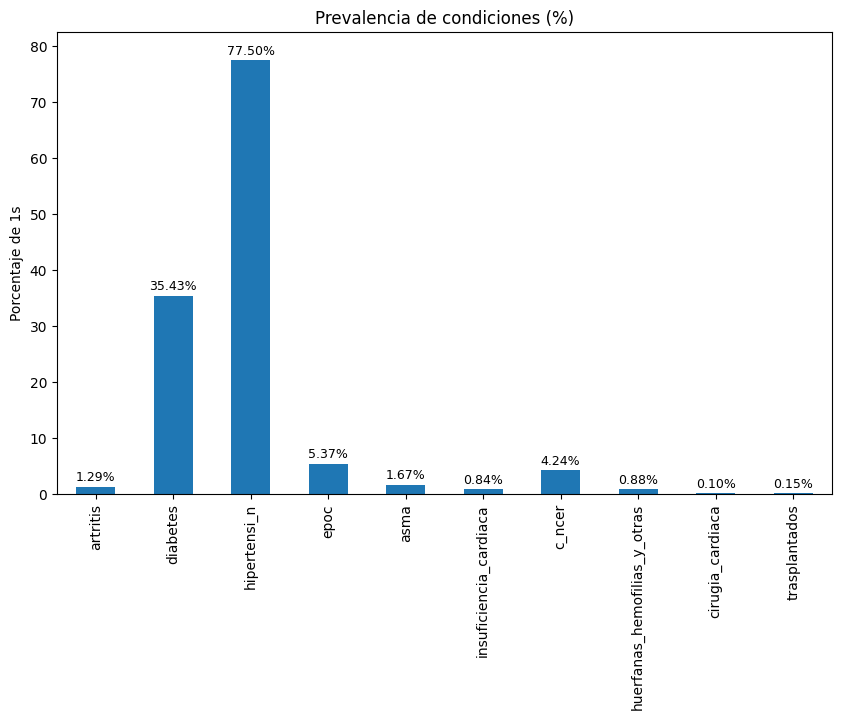

In [ ]:
#Analisis de las variables Binarias
binary_vars = [
    "artritis","diabetes","hipertensi_n","epoc","asma",
    "insuficiencia_cardiaca","c_ncer","huerfanas_hemofilias_y_otras",
    "cirugia_cardiaca","trasplantados"
]

# Calcular prevalencia en %
prevalencias = df_final[binary_vars].mean() * 100

# Gráfico de barras
ax = prevalencias.plot(kind="bar", figsize=(10,6))
plt.title("Prevalencia de condiciones (%)")
plt.ylabel("Porcentaje de 1s")
plt.ylim(0, prevalencias.max() + 5)  # un poco de espacio arriba

# Añadir anotaciones de % encima de cada barra
for i, v in enumerate(prevalencias):
    plt.text(i, v + 0.5, f"{v:.2f}%", ha="center", va="bottom", fontsize=9)

plt.show()

In [1]:
#Analisis de las variables categoricas


# Variables categóricas
var_cat = ['sexo', 'regimen', 'ciclo_de_vida', 'tipo_erc_limpio', 'erc_trr_limpio']

for var in var_cat:
    # Calcular proporciones
    proporciones = df_final[var].value_counts(normalize=True) * 100

    # Gráfico de barras horizontales
    ax = proporciones.plot(kind="barh", figsize=(8,4))
    plt.title(f'Distribución de {var}')
    plt.xlabel("Proporción (%)")
    plt.ylabel("Categoría")

    # Añadir etiquetas a cada barra
    for i, v in enumerate(proporciones):
        ax.text(v + 0.5, i, f"{v:.2f}%", va="center", fontsize=9)

    plt.show()

NameError: name 'df_final' is not defined

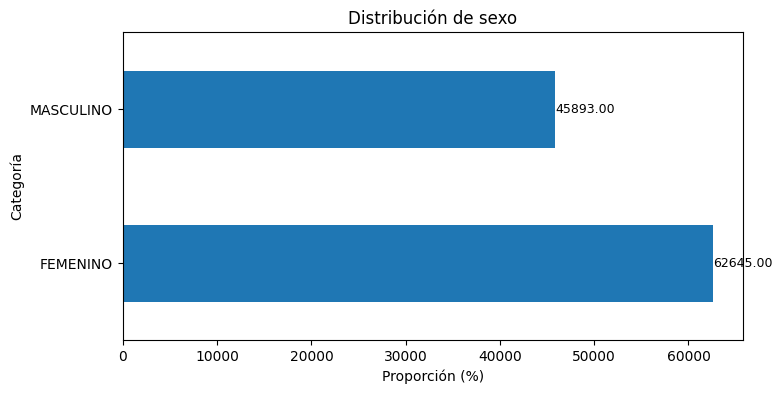

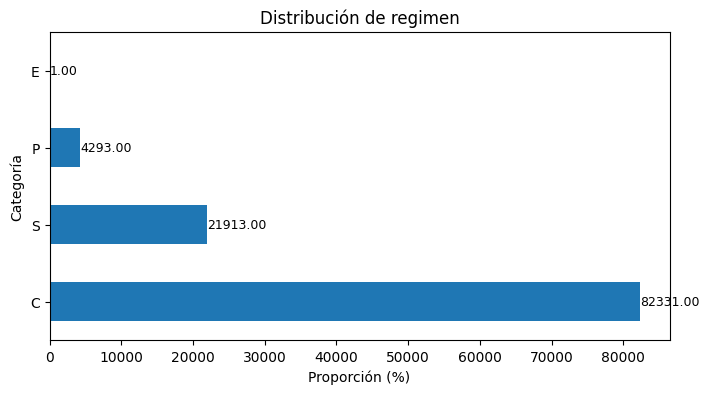

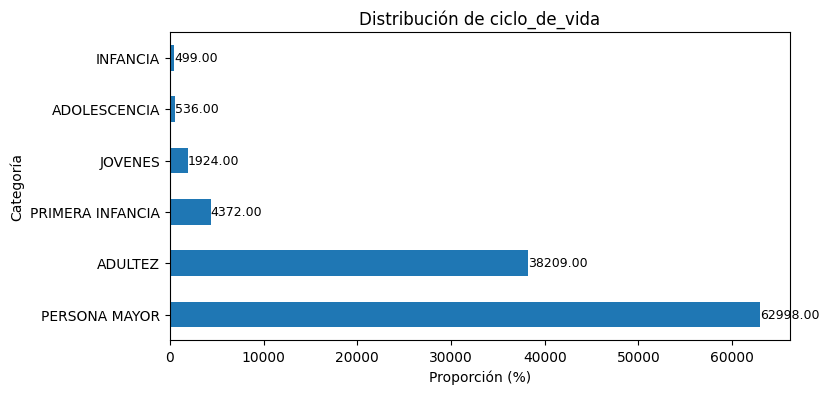

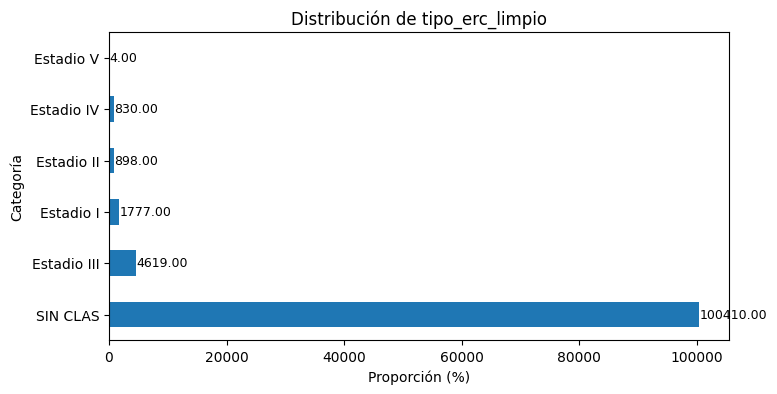

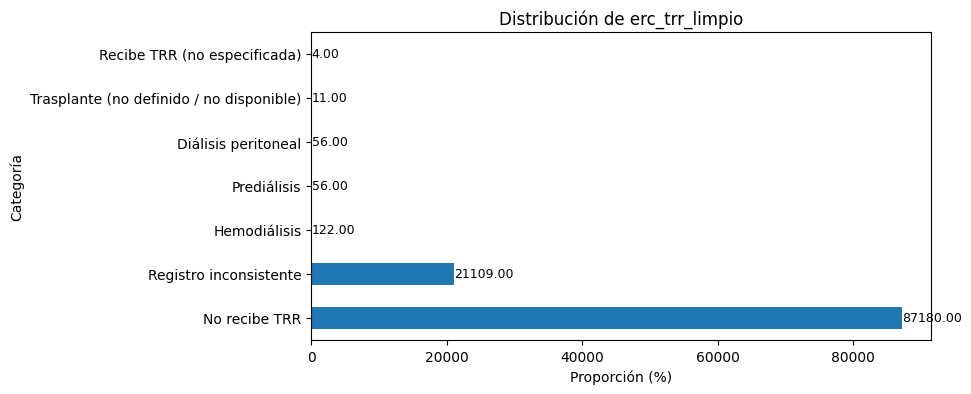

In [ ]:
#Analisis de las variables categoricas


# Variables categóricas
var_cat = ['sexo', 'regimen', 'ciclo_de_vida', 'tipo_erc_limpio', 'erc_trr_limpio']

for var in var_cat:
    # Calcular proporciones
    proporciones = df_final[var].value_counts(normalize=False)

    # Gráfico de barras horizontales
    ax = proporciones.plot(kind="barh", figsize=(8,4))
    plt.title(f'Distribución de {var}')
    plt.xlabel("Proporción (%)")
    plt.ylabel("Categoría")

    # Añadir etiquetas a cada barra
    for i, v in enumerate(proporciones):
        ax.text(v + 0.5, i, f"{v:.2f}", va="center", fontsize=9)

    plt.show()

In [ ]:
# Analisis Bi-Variado

for var_cros_tab in var_cat:

    tabla = pd.crosstab(df_final[var_cros_tab], df_final["diabetes"], normalize="index") * 100
    print(f"\nPrevalencia de diabetes según {var_cros_tab}:")
    print(tabla)


Prevalencia de diabetes según sexo:
diabetes           0          1
sexo                           
FEMENINO   64.755368  35.244632
MASCULINO  64.319177  35.680823

Prevalencia de diabetes según regimen:
diabetes           0          1
regimen                        
C          67.056151  32.943849
E         100.000000   0.000000
P          49.429304  50.570696
S          58.198330  41.801670

Prevalencia de diabetes según ciclo_de_vida:
diabetes                  0          1
ciclo_de_vida                         
ADOLESCENCIA      92.537313   7.462687
ADULTEZ           67.476249  32.523751
INFANCIA          96.793587   3.206413
JOVENES           83.004158  16.995842
PERSONA MAYOR     61.090828  38.909172
PRIMERA INFANCIA  74.107960  25.892040

Prevalencia de diabetes según tipo_erc_limpio:
diabetes                 0          1
tipo_erc_limpio                      
Estadio I        61.057963  38.942037
Estadio II       69.265033  30.734967
Estadio III      66.442953  33.557047
Estadio

## 🔎 Sexo

Femenino: 35.24% con diabetes.

Masculino: 35.68% con diabetes.
👉 Diferencia mínima → sexo no parece ser un predictor fuerte de diabetes.

## 🔎 Régimen

Contributivo (C): 32.9% con diabetes.

Subsidiado (S): 41.8% con diabetes.

Particular (P): 50.6% con diabetes.

Especial (E): 0%, pero seguramente por muy pocos registros.
👉 Aquí sí hay un patrón: la probabilidad de diabetes aumenta en régimen particular y subsidiado respecto al contributivo.
Este campo parece discriminante.

## 🔎 Ciclo de vida

Persona mayor: 38.9% con diabetes.

Adultez: 32.5% con diabetes.

Jóvenes: 17% con diabetes.

Adolescencia e infancia: muy bajo (<8%).
👉 Hay una clara asociación etaria: a mayor edad, mayor prevalencia de diabetes.
Esto es lógico y clínicamente consistente.

## 🔎 Tipo ERC limpio

Sin clasificación: ~35.5%.

Estadio I–IV: oscilan entre 30–39%.

Estadio V: 50%, pero con pocos casos (cuidado con sobreinterpretar).
👉 En general, la presencia de enfermedad renal crónica (ERC) en cualquier estadio se asocia a prevalencias iguales o mayores que la media → relación positiva entre ERC y diabetes (esperado por la literatura).

## 🔎 ERC TRR limpio (tratamiento de reemplazo renal)

Hemodiálisis: 51.6% con diabetes.

Diálisis peritoneal: 57.1% con diabetes.

Prediálisis: 42.8% con diabetes.

No recibe TRR: 35.7% (similar a la media).
👉 Pacientes en tratamiento renal avanzado tienen prevalencias mucho más altas de diabetes.
Esto es coherente, porque diabetes es un factor de riesgo de ERC terminal.

## 🎯 Conclusiones de exploración

Sexo → no aporta mucha información.

Régimen → sí marca diferencias; el contributivo tiene menor prevalencia.

Ciclo de vida → variable clave; a mayor edad, mayor prevalencia.

ERC y TRR → fuerte asociación con diabetes (biológicamente consistente).

Algunas categorías con prevalencia extrema (ej. Estadio V, TRR no especificada, Régimen E) deben tomarse con cuidado porque tienen muy pocos registros.

👉 En resumen: tus variables regimen, ciclo_de_vida y erc/erc_trr_limpio aportan valor predictivo real para el modelo de diabetes.
El sexo, en cambio, probablemente no mejore el rendimiento del clasificador.



In [ ]:
#Prueba CHI2
from sklearn.feature_selection import chi2, mutual_info_classif
from sklearn.preprocessing import LabelEncoder

# Variables categóricas

var = ['sexo', 'regimen', 'artritis', 'hipertensi_n', 'epoc',
       'asma', 'insuficiencia_cardiaca', 'c_ncer',
       'huerfanas_hemofilias_y_otras', 'cirugia_cardiaca', 'trasplantados',
       'ciclo_de_vida', 'compromiso_renal', 'tipo_erc_limpio',
       'erc_trr_limpio']

# Copia de df para trabajar
df_aux = df_final.copy()

# Codificar las variables categóricas a números
encoders = {}
for col in var:
    le = LabelEncoder()
    df_aux[col] = le.fit_transform(df_aux[col].astype(str))
    encoders[col] = le

# X = solo categóricas
X = df_aux[var]
y = df_aux["diabetes"]

# --- 1) Chi2 ---
chi2_vals, p_vals = chi2(X, y)
chi2_results = pd.DataFrame({
    "Variable": var,
    "Chi2": chi2_vals,
    "p-valor": p_vals
}).sort_values("Chi2", ascending=False)

print("Resultados Chi2:")
print(chi2_results)

# --- 2) Mutual Information ---
mi = mutual_info_classif(X, y, discrete_features=True, random_state=42)
mi_results = pd.DataFrame({
    "Variable": var,
    "Mutual_Info": mi
}).sort_values("Mutual_Info", ascending=False)

print("\nResultados Mutual Information:")
print(mi_results)

mi_results.to_excel('/content/drive/MyDrive/1. Proyectos/e. Proyecto Predicción de enfermedades crónicas en Bucaramanga/Datasets/mi_result.xlsx')
chi2_results.to_excel('/content/drive/MyDrive/1. Proyectos/e. Proyecto Predicción de enfermedades crónicas en Bucaramanga/Datasets/chi2_result.xlsx')

Resultados Chi2:
                        Variable         Chi2        p-valor
1                        regimen  1771.934597   0.000000e+00
12              compromiso_renal   969.762578  6.712626e-213
5                           asma   615.861071  5.942429e-136
4                           epoc   481.851163  8.451551e-107
7                         c_ncer   467.872800  9.303904e-104
3                   hipertensi_n   423.236858   4.818504e-94
2                       artritis   340.145903   5.930559e-76
8   huerfanas_hemofilias_y_otras   294.567094   5.028683e-66
11                 ciclo_de_vida   240.599792   2.910213e-54
10                 trasplantados    21.755779   3.096557e-06
14                erc_trr_limpio    13.620620   2.237148e-04
6         insuficiencia_cardiaca     1.726824   1.888170e-01
0                           sexo     1.271484   2.594884e-01
9               cirugia_cardiaca     0.524853   4.687789e-01
13               tipo_erc_limpio     0.077344   7.809298e-01

Result

In [ ]:
df.columns

## 🔎 Interpretación de resultados
### Chi² (significancia estadística)

regimen → Chi² = 1771.9, p < 0.00001 → fuertísima asociación.

ciclo_de_vida → Chi² = 240.6, p < 0.00001 → muy relevante.

erc_trr_limpio → Chi² = 13.6, p < 0.001 → asociación moderada.

sexo → p = 0.25 → no significativa.

tipo_erc_limpio → p = 0.078 → tampoco significativa al 5%.

👉 Según Chi², regimen y ciclo_de_vida son las variables clave, erc_trr_limpio aporta algo, pero las demás no.

## Mutual Information (dependencia en general)

ciclo_de_vida (0.0070) y regimen (0.0047) → son las que más aportan información.

erc_trr_limpio aporta poco (0.0023).

tipo_erc_limpio y sexo → prácticamente nulos.

👉 Confirma que la edad (ciclo_de_vida) y el régimen son las que más valor predictivo tienen.

## 🎯 Conclusiones prácticas para tu modelo

Variables más útiles para predecir diabetes:

ciclo_de_vida

regimen

erc_trr_limpio (aunque más débil, puede ayudar).

Variables con bajo aporte:

sexo

tipo_erc_limpio
👉 Puedes excluirlas del modelo inicial para evitar ruido.

Estrategia

Entrenar modelos con todas las variables y luego con las más relevantes (ciclo_de_vida + regimen + erc_trr_limpio).

Compara métricas → si no hay pérdida de rendimiento, quédate con las relevantes (simplificas el modelo).

In [ ]:
  df_final['sexo'].unique()

  #Reemplazamos la variable sexo por valores binarios

  df_final['sexo_MASCULINO'] = df_final['sexo'].replace({"MASCULINO":1, "FEMENINO":0})

In [ ]:
df_final

In [ ]:
#Eliminamos la columna de sexo que ya esta convertida
df_final = df_final.drop(columns='sexo')

In [ ]:
#Ahora, las variables categoricas las debemos dummificar con ONE HOT ENCODER

from sklearn.preprocessing import OneHotEncoder

vars_one_hot_encoder= ['ciclo_de_vida', 'tipo_erc_limpio','erc_trr_limpio','regimen'] #Listamos las variables a codificar

#Creamos el Codificador
encoder = OneHotEncoder(drop="first", sparse_output=False)

#Ajustamos y transformamos
encoded = encoder.fit_transform(df_final[vars_one_hot_encoder])

#Convertimos a df
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(vars_one_hot_encoder))

#Ahota tenemos dos conjuntos diferentes pero debemos concatenar el df encoded y el df originar borrando las variables originales que codificamos
# Concatenar con el resto del dataset
df_encoded = pd.concat(
    [df_final.drop(columns=vars_one_hot_encoder).reset_index(drop=True), #Primer dd
     encoded_df.reset_index(drop=True)],
    axis=1
)



df_encoded.head()


In [ ]:
df_encoded.isnull().sum()

In [ ]:
df_final.duplicated().sum()

In [ ]:
len(df_final)

In [ ]:
# ¿Cuántas filas únicas hay?
n_unicas = df_final.drop_duplicates().shape[0]
n_total  = df_final.shape[0]
n_dups   = n_total - n_unicas
print(f"Únicas: {n_unicas} | Duplicadas: {n_dups} ({n_dups/n_total:.2%})")

# Marcar TODAS las filas que pertenecen a grupos duplicados (incluye la primera)
mask_dups_all = df_final.duplicated(keep=False)
df_dups = df_final[mask_dups_all]
df_no_dups = df_final.drop_duplicates()


In [ ]:
n_total  = df_final.shape[0]
n_unicas = df_final.drop_duplicates().shape[0]
n_dups   = n_total - n_unicas

print(f"Filas totales: {n_total}")
print(f"Filas únicas: {n_unicas}")
print(f"Duplicadas exactas: {n_dups} ({n_dups/n_total:.2%})")


## Análisis de duplicados

- **Filas totales:** 108,538  
- **Filas únicas:** 1,701  
- **Duplicadas exactas:** 106,837 (98.43%)  

### Interpretación
- La mayoría de los registros comparten exactamente el mismo perfil de variables, es decir, **distintos pacientes tienen combinaciones idénticas** en las columnas finales.  
- Esto **no es un error de datos**, sino que refleja la repetición natural de perfiles clínicos en la población.  

### Riesgos
- **Fuga de información:**  
  Si se realiza un `train_test_split` clásico, un mismo perfil puede quedar en `train` y en `test`.  
  El modelo ya habría visto ese patrón antes, inflando artificialmente las métricas.  

### Solución adoptada
- Usar **GroupShuffleSplit** agrupando por perfil completo de variables.  
- De esta forma, **ningún perfil idéntico aparece en train y test al mismo tiempo**, lo que evita la fuga de información y asegura una evaluación justa del modelo.


### ✅ ¿Se pierde información con `GroupShuffleSplit`?

No 🚫.  

- Todos los registros siguen estando en el dataset (solo se reparten entre train y test).  
- La diferencia es que **la partición ya no es aleatoria a nivel de fila**, sino a nivel de grupo.  

**Ejemplo:**  
- Tienes 100,000 registros y 1,700 perfiles únicos.  
- `GroupShuffleSplit(train_size=0.7)` → selecciona el 70% de los **perfiles** (≈1,190 perfiles) para train y el 30% restante para test.  
- Eso corresponde a todos los pacientes que tienen esos perfiles (ej: si un perfil se repite 2,000 veces, todos esos 2,000 van juntos a train o a test).  

---

### ⚠️ Diferencia con un `train_test_split` normal

- En un split normal: el mismo perfil puede aparecer en train **y** test → fuga de información.  
- En `GroupShuffleSplit`: cada perfil completo queda **solo en train o en test**.  
- Esto puede hacer que el split no quede exactamente 70/30 en cantidad de filas, pero la diferencia suele ser mínima.  

---

### 🎯 Conclusión

- **Sí, conserva toda la información** (no elimina filas).  
- La única diferencia es que la partición es por grupos en lugar de filas → lo cual es justo lo que necesitas para evitar inflar las métricas.  



In [ ]:
# Exportar DataFrame final a CSV
ruta_salida ='/content/drive/MyDrive/1. Proyectos/e. Proyecto Predicción de enfermedades crónicas en Bucaramanga/Datasets/df_procesado_bucaramanga.csv'

# index=False evita que se guarde la columna de índice
df_encoded.to_csv(ruta_salida, index=False, encoding="utf-8")

print(f"✅ Dataset exportado correctamente a: {ruta_salida}")

In [ ]:
df_encoded